# Online learning — policy comparison over multiple seeds (Model 1, restructured)

Same experiment as `03_online_learning_whole_pop.ipynb` (whole-population ranking: every
round score all not-yet-enrolled patients with the current forest, enrol the top
`batch_size` with their real historical `(T, Y)`, refit, repeat), restructured so that the
enrolment loop exists **once** instead of once per acquisition score.

> **Run status:** the embedded outputs predate both the +45°/-45° Angle split and the corrected scalar convention (`conflict = bleed - isch`, `net_benefit = bleed + isch`). Rerun before using any scalar or Angle numerical result. When a legacy file is loaded below, its duplicate +45° `angle_conflict` rows are omitted rather than presented as results for the current -45° policy.

What changed relative to nb 03:

1. **One loop.** `run_enrollment(prep, policy=...)` replaces `run_ranked_enrollment`,
   `run_ranked_enrollment_net_benefit` and `run_ranked_enrollment_angle`, which were three
   near-identical copies. Every difference between them now lives in a single entry of the
   `POLICIES` registry (which CATE frame to build, how to turn it into a score).
2. **The policy is a variable.** `POLICIES` holds the four unchanged scalar policies,
   two distinct Angle policies (`angle_net_benefit` at +45° and `angle_conflict` at -45°),
   and `random` as the control arm.
3. **Multi-seed by default.** Every policy is run over `N_RUNS` independent seed cohorts and
   reported as a mean ± SEM across runs, instead of the single-seed runs of nb 03/04. A
   single enrolment run picks 100 out of a cohort with a ~5% ischaemic event
   rate, so per-batch counts are dominated by sampling noise; only the across-seed average
   is readable.

Three diagnostics per policy, all averaged over seeds:

* **Ischaemic patients in the two groups** (enrolled vs left-out), as raw counts and as
  rates, over the course of enrolment.
* **Ischaemic patients added per batch** — the mean number of new ischaemic-event patients
  each policy pulls in per batch of `BATCH_SIZE`.
* **CATE drift** — where the enrolled sub-population sits on the (bleed, ischaemic) CATE
  plane of a **fixed full-cohort reference model**, versus the full-cohort mean. Using one
  frozen reference model for all policies makes the drift comparable across them and
  separates genuine population drift from refit-to-refit noise of the online forest.

In [12]:
%load_ext autoreload
%autoreload 2
# Reloads edited .py modules (online_learning_utils, casual_multioutput_pipeline, ...) before every
# cell, so changes to their source take effect without restarting the kernel.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')                       # silence LGBM feature-name / small-sample notes

SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

Xn = X.select_dtypes(include=[np.number])                                        # numeric design matrix (nb 06)
T  = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()   # 1=prolonged, 0=shortened
ENDPOINTS = {'bleed': 'cec_bleed_335d', 'death': 'cec_cvdeath_335d',
             'mi': 'cec_mi_335d', 'stroke': 'cec_stroke_335d'}
N = len(T)
print('patients:', N, '| prolonged:', int(T.sum()), 'shortened:', int((T == 0).sum()))

patients: 4579 | prolonged: 2284 shortened: 2295


In [14]:
# ---------------------------------------------------------------------------
# Base-model flexibility presets
# ---------------------------------------------------------------------------
# Three hand-set configurations that scale the *flexibility* of the whole
# estimator -- both the causal forest itself and its first-stage LGBM nuisances
# -- from strongly regularized to highly flexible. They turn the single
# Optuna-tuned model into an explicit sensitivity analysis: if no CATE
# heterogeneity survives even the flexible model (and the regularized one
# collapses cleanly toward the ATE), the homogeneous-effect conclusion is robust
# to model capacity rather than an artefact of one hyper-parameter choice.
#
# Regularization levers (less flexible <- ... -> more flexible)
#   forest   : max_depth (shallow), min_samples_leaf (large),
#              max_samples (small per-tree subsample), min_balancedness_tol
#              (small -> more balanced splits), min_impurity_decrease (gate
#              against spurious splits).
#   nuisance : max_depth / num_leaves (shallow), min_child_samples (large),
#              n_estimators (few), reg_lambda (stronger L2).
#
# n_estimators are kept divisible by the forest's default subforest_size (4).
CF_MODEL_PRESETS = {
    'regularized': {
        'cf_params': {
            'n_estimators': 400,
            'max_depth': 2,
            'min_samples_leaf': 40,
            'max_samples': 0.30,
            'min_balancedness_tol': 0.30,
            'min_impurity_decrease': 0.0001
        },
        'nuisance_params': {
            'n_estimators': 50,
            'max_depth': 2,
            'num_leaves': 4,
            'min_child_samples': 40,
            'learning_rate': 0.05,
            'reg_lambda': 1.0,
        },
    },
    'medium': {
        'cf_params': {
            'n_estimators': 500,
            'max_depth': 4,
            'min_samples_leaf': 15,
            'max_samples': 0.40,
        },
        'nuisance_params': {
            'n_estimators': 100,
            'max_depth': 4,
            'num_leaves': 15,
            'min_child_samples': 20,
            'learning_rate': 0.05,
        },
    },
    'flexible': {
        'cf_params': {
            'n_estimators': 600,
            'max_depth': 8,
            'min_samples_leaf': 5,
            'max_samples': 0.50,
        },
        'nuisance_params': {
            'n_estimators': 300,
            'max_depth': 8,
            'num_leaves': 63,
            'min_child_samples': 5,
            'learning_rate': 0.03,
        },
    },
}

In [15]:
CF_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'Meta-learning', 'causal_forest'))
sys.path.insert(0, CF_DIR)
SCRIPTS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'scripts'))
sys.path.insert(0, SCRIPTS_DIR)
from casual_multioutput_pipeline import CausalMultiOutputPipeline, CF_MODEL_PRESETS
from online_learning_utils import (quiet_toc_warnings, z, fit_cate, conflict_from_model,
                                    weighted_isch,
                                    DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)

ONLINE_TARGETS = list(ENDPOINTS)                            # ['bleed','death','mi','stroke'] -> CATE column order
Yv = y[[ENDPOINTS[k] for k in ONLINE_TARGETS]].to_numpy()
BLEED_IDX = ONLINE_TARGETS.index('bleed')                   # seed tuning targets the bleeding endpoint (nb 06 convention)
#ISCH_WEIGHTS = {'death': 0.2, 'mi': 0.4, 'stroke': 0.4}    # ischaemic weighting for conflict_from_model
ISCH_WEIGHTS = {'death': 0, 'mi': 0, 'stroke': 1}    # ischaemic weighting for all policies

# DEFAULT_CF_PARAMS / DEFAULT_NUISANCE_PARAMS are imported above from online_learning_utils:
# the single canonical light default forest shared by nb 02 / 02_bandits / 03 / 04 / 05, so runs
# of different notebooks are comparable by construction. Do NOT redefine them in this cell --
# a local copy shadows the import and silently re-forks the configuration; edit the module.

def uncertainty_from_model(model):
    """Score EVERY patient with the current model and rebuild the uncertainty frame (nb 02)."""
    #X_df = pd.DataFrame(Xn, columns=X.columns)
    cate = model.predict_cate_std(Xn.values)
    df = pd.DataFrame({k: cate[:, ONLINE_TARGETS.index(k)] for k in ENDPOINTS})
    df['uncertainty'] = z(df['bleed']) + weighted_isch({k: z(df[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
    return df

In [16]:
def seed_draw(n_seed, seed=0, n_test=0, verbose=True):
    """Draw the arrival order and split it into seed / stream / holdout."""
    rng        = np.random.default_rng(seed)
    order      = rng.permutation(N)
    stream_end = N - n_test
    seed_idx   = list(order[:n_seed])
    test_idx   = list(order[stream_end:])
    if verbose:
        print(f'PHASE 1  seed drawn: {n_seed} patients  |  '
              f'pool: {stream_end - n_seed}  |  held-out: {n_test}')
    return dict(rng=rng, order=order, seed_idx=seed_idx,
                test_idx=test_idx, stream_end=stream_end)


def tune_seed(seed_idx, seed=0, n_trials=0, tune_cv=3, n_jobs=32, lgbm_n_jobs=16,
              verbose=True):
    """Fit the light default forest on `seed_idx`, then optionally hyper-tune it
    (n_trials=0 skips the search and keeps DEFAULT_CF_PARAMS).

    Optuna runs its trials sequentially (`optuna_n_jobs=1`): its own `n_jobs` spawns THREADS
    and `score_cv_autoc` is almost pure Python, so parallel trials mostly contend for the GIL
    while each still spawns its own `n_jobs`/`lgbm_n_jobs` workers -- and when `tune_seed` is
    itself called from inside a joblib worker the product oversubscribes the machine. All the
    parallelism comes from `n_jobs`/`lgbm_n_jobs`, sized by the caller against its own budget."""
    if n_trials:
        from online_learning_utils import tune_on_seed
        cf_params, nuisance_params, study = tune_on_seed(
            seed_idx, Xn, Yv, T, CausalMultiOutputPipeline, CF_MODEL_PRESETS,
            BLEED_IDX, n_trials=n_trials, cv=tune_cv, seed=seed,
            optuna_n_jobs=1, n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        if verbose:   # 48 workers tuning at once would interleave this into mush
            print(f'         hyper-tuned: best CV score = {study.best_value:+.4f}')
    else:
        cf_params, nuisance_params = DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS
    return cf_params, nuisance_params, None


def seed_fit_tune(n_seed, seed=0, n_trials=0, n_test=0, verbose=False,
                  n_jobs=32, lgbm_n_jobs=16):
    """PHASE 1 -- seed, fit, hyper-tune. Returns the prep dict Phase 2 expects."""
    prep = seed_draw(n_seed, seed=seed, n_test=n_test, verbose=verbose)
    cf_params, nuisance_params, _ = tune_seed(prep['seed_idx'], seed=seed, n_trials=n_trials,
                                              n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs,
                                              verbose=verbose)
    return {**prep, 'cf_params': cf_params, 'nuisance_params': nuisance_params}

## Reference model — the fixed yardstick for CATE drift

The full-cohort reference forest is never used for selection. It supplies frozen, uncentred
bleeding and weighted-ischaemic axes for describing the population chosen by each online
policy. Their zero is the clinical no-effect point; they are not the median-centred Angle
decision coordinates.

The scalar convention is fixed throughout:

- **conflict / trade-off** = `bleed - weighted_isch`;
- **net-benefit / win-win** = `bleed + weighted_isch`.

For Angle selection, both policies derive median-centred `x_plane` / `y_plane` coordinates
from the current online model. Angle net-benefit uses `(x,y)` and +45°. Angle conflict applies
`y -> -y` before every geometric calculation, corresponding to -45° on the original plane.

In [17]:
reference_model = fit_cate(list(range(N)), Xn, Yv, T, CausalMultiOutputPipeline,
                           DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)
reference_conflict = conflict_from_model(reference_model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)

REF_BLEED = reference_conflict['bleed'].to_numpy()                                     # x axis
REF_ISCH  = weighted_isch({k: reference_conflict[k] for k in ISCH_WEIGHTS},
                          ISCH_WEIGHTS).to_numpy()                                     # y axis
REF_Q1    = (REF_BLEED > 0) & (REF_ISCH > 0)                                           # win-win quadrant

FULL_BLEED, FULL_ISCH = REF_BLEED.mean(), REF_ISCH.mean()
FULL_NET_BENEFIT, FULL_Q1 = (REF_BLEED + REF_ISCH).mean(), REF_Q1.mean()

print(f'full-cohort reference:  bleed CATE={FULL_BLEED:+.4f}  isch CATE={FULL_ISCH:+.4f}  '
      f'net benefit={FULL_NET_BENEFIT:+.4f}  win-win fraction={FULL_Q1:.1%}')

# Real observed outcomes, precomputed once as positional boolean masks: every count in the
# loop below is then a mask lookup instead of a per-round pandas index scan.
ISCH_ANY  = ((y[ENDPOINTS['death']].to_numpy()  == 1) |
             (y[ENDPOINTS['mi']].to_numpy()     == 1) |
             (y[ENDPOINTS['stroke']].to_numpy() == 1))
BLEED_ANY = y[ENDPOINTS['bleed']].to_numpy() == 1
print(f'observed events in the full cohort: ischaemic={ISCH_ANY.sum()} ({ISCH_ANY.mean():.2%})  '
      f'bleeding={BLEED_ANY.sum()} ({BLEED_ANY.mean():.2%})')

full-cohort reference:  bleed CATE=+4.4304  isch CATE=+1.5405  net benefit=+5.9709  win-win fraction=97.2%
observed events in the full cohort: ischaemic=205 (4.48%)  bleeding=506 (11.05%)


## The policy registry — the only place the seven policies differ

Each registry entry specifies a CATE frame and a scorer imported from
`online_learning_policies.py`:

* **`conflict`** — z-scored `bleed - weighted_isch`, plus uncertainty: the scalar trade-off
  difference.
* **`net_benefit`** — z-scored `bleed + weighted_isch`, plus uncertainty: the scalar
  net-benefit / win-win sum.
* **`-isch`** and **`+isch`** — the unchanged single-axis directions.
* **`angle_net_benefit`** — centred `(x,y)`, preferred Q1, target +45°.
* **`angle_conflict`** — applies `y -> -y` before quadrant tiers, magnitude and angular
  distance; equivalently it prefers original centred Q4 and targets -45°.
* **`random`** — uniform random order without a model.

The Angle scorers do not read either scalar column. The shared `c` parameter controls the
uncertainty bonus for every non-random policy.

In [18]:
def ischemic_damage_from_model(model, X, endpoints, weights, targets, scale=True): #different version of the function conflict_from_model, which is used in 05_online_learning_policy_comparison_monodim.ipynb

    from sklearn.preprocessing import RobustScaler

    cate = model.predict_cate(X.values)
    df   = pd.DataFrame({k: cate[:, targets.index(k)] for k in endpoints})

    if scale:
        cols = list(endpoints)
        df[cols] = RobustScaler(with_centering=False).fit_transform(df[cols])

    df['-isch'] = -weighted_isch(df, weights)
    return df

def ischemic_gain_from_model(model, X, endpoints, weights, targets, scale=True): #different version of the function conflict_from_model, which is used in 05_online_learning_policy_comparison_monodim.ipynb

    from sklearn.preprocessing import RobustScaler

    cate = model.predict_cate(X.values)
    df   = pd.DataFrame({k: cate[:, targets.index(k)] for k in endpoints})

    if scale:
        cols = list(endpoints)
        df[cols] = RobustScaler(with_centering=False).fit_transform(df[cols])

    df['+isch'] = weighted_isch(df, weights)
    return df

In [19]:
from online_learning_utils import (z, fit_cate, weighted_isch, conflict_from_model,
                                   net_benefit_from_model)
from online_learning_policies import (SCORE_CONVENTION, score_angle_conflict, score_angle_net_benefit,
                                      score_conflict, score_minus_isch,
                                      score_net_benefit, score_plus_isch)



POLICIES = {
    'conflict': dict(
        label='Conflict (bleed - isch)', short='Conflict', color='steelblue',
        frame=lambda model: conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS),
        score=score_conflict,
    ),
    'net_benefit': dict(
        label='Net benefit / win-win (bleed + isch)', short='Net benefit', color='darkorange',
        frame=lambda model: net_benefit_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS),
        score=score_net_benefit,
    ),
    '-isch': dict(
        label='-isch', short='-isch', color='#00838F',
        frame=lambda model: ischemic_damage_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS),
        score=score_minus_isch,
    ),
    '+isch': dict(
        label='+isch', short='+isch', color='#C2185B',
        frame=lambda model: ischemic_gain_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS),
        score=score_plus_isch,
    ),
    'angle_net_benefit': dict(
        label='Angle net-benefit (+45 deg)', short='Angle NB (+45)', color='#7B3FA0',
        # Both Angle policies use this same plane; neither reads the scalar conflict column.
        frame=lambda model: conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS),
        score=lambda frame, unc, idx, c: score_angle_net_benefit(frame, unc, idx, ISCH_WEIGHTS, c=c),
    ),
    'angle_conflict': dict(
        label='Angle conflict (-45 deg)', short='Angle conflict (-45)', color='darkgreen',
        frame=lambda model: conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS),
        score=lambda frame, unc, idx, c: score_angle_conflict(frame, unc, idx, ISCH_WEIGHTS, c=c),
    ),
    'random': dict(
        label='random (control)', short='random', color='grey',
        frame=None,          # no CATE -> the loop skips the forest altogether
        score=None,
    ),
}

## The enrolment loop — declared once

`run_enrollment` rebuilds the selected policy's frame after each refit and records observed
events plus frozen-reference diagnostics.

| column | meaning |
|---|---|
| `n`, `batch_n` | enrolled so far and size of the current batch |
| `batch_isch_n`, `batch_bleed_n` | events in the patients added this batch |
| `new_*` | actively selected cohort, excluding the random seed |
| `left_*` | patients still outside the cohort |
| `ref_bleed`, `ref_isch` | mean frozen-reference CATE on the two uncentred axes |
| `ref_net_benefit` | frozen-reference sum `REF_BLEED + REF_ISCH` |
| `ref_q1_frac` | clinical-zero win-win fraction (`REF_BLEED>0`, `REF_ISCH>0`) |
| `batch_q1_online` | the same raw-zero condition under the current online model |
| `autoc_lb` | checkpoint AUTOC lower bound |

The raw-zero Q1 fractions are descriptive and are not direct measures of the centred Angle
tiers. Exact Angle diagnostics would use centred Q1 for Angle net-benefit and original centred
Q4 for Angle conflict.

In [20]:
def sample_batch(score, pool, batch_size, temperature=0.0, rng=None):
    """Select `batch_size` patients from `pool` given their `score`.
    temperature=0   -> greedy top-k
    temperature>0   -> stochastic sampling without replacement, softmax(score / temperature)

    Gumbel-top-k trick (add i.i.d. Gumbel noise to the logits, then argsort) rather than
    building `p = softmax(...)` and calling `rng.choice(..., p=p)`: once `temperature` decays
    far enough most entries underflow to exactly 0.0 and `rng.choice(replace=False, p=p)`
    raises `ValueError: Fewer non-zero entries in p than size`. Gumbel-top-k samples from the
    identical Plackett-Luce distribution but never normalises a probability vector, so it
    stays exact at any temperature."""
    score = np.asarray(score, dtype=float)
    pool  = np.asarray(pool)
    n     = min(batch_size, len(pool))

    if temperature <= 0:
        return pool[np.argsort(score)[::-1][:n]]

    rng    = rng or np.random.default_rng()
    gumbel = -np.log(-np.log(rng.random(len(pool))))
    return pool[np.argsort(score / temperature + gumbel)[::-1][:n]]


def run_enrollment(prep, policy='conflict', batch_size=100, c=0.0, verbose=True,
                   N_STOP=None, temperature0=0.0, decay_rate=5.0, seed=SEED,
                   autoc_every=None, autoc_cv=3, autoc_target_idx=None,
                   unc_every=None, tune_every=None, tune_trials=0, refit_trials=0,
                   fit_n_jobs=32, lgbm_n_jobs=16):
    """Rank every not-yet-enrolled patient each round with `POLICIES[policy]`, enrol the top
    `batch_size` with their real historical treatment and outcome, refit, repeat until the
    pool is exhausted or `N_STOP` patients are enrolled.

    `policy`      : key into `POLICIES`. `'random'` skips the forest entirely (control arm).
    `c`           : UCB1 exploration weight, ignored by `'random'`.
    `temperature0`/`decay_rate` : annealed stochastic batch selection (0 = greedy top-k).
    `autoc_every` : if set, recompute the cross-validated AUTOC lower bound on the enrolled
                    cohort each time `len(enrolled)` crosses a multiple of it. Expensive.
    `unc_every`   : if set, record the forest's own per-patient CATE standard errors at the
                    same kind of cadence (one `predict_cate_std` call, ~2.4 s). Independent of
                    `c`: at `c == 0` the acquisition score throws the uncertainty away, but the
                    diagnostic still wants it recorded.
    `tune_every`  : MUST STAY `None`, as must `refit_trials=0`. Both re-tune
                    `cf_params`/`nuisance_params` on the *enrolled* cohort. The seed is the last cohort still drawn at random, so it is the only one whose covariate
    distribution is the population's and the only one on which the tuning objective targets
    the population estimand. Past it the enrolled cohort is one the mechanism itself chose:
    re-tuning there optimises the AUTOC of a population that the configuration being scored
    has constructed, so configurations no longer share a yardstick; the distortion cannot even
    be signed (selecting the head of the ranking compresses the spread of tau and attenuates
    AUTOC, while concentrating training data in the selected region inflates it); and
    cross-validation cannot detect any of it, because every fold has passed the same
    selection filter.
    """
    pol = POLICIES[policy]
    needs_model = pol['frame'] is not None

    cf_params, nuisance_params = prep['cf_params'], prep['nuisance_params']
    seed_set = set(prep['seed_idx'])
    enrolled = list(prep['seed_idx'])

    in_pool = np.ones(N, dtype=bool)
    in_pool[enrolled] = False
    pool = np.flatnonzero(in_pool)

    rng           = np.random.default_rng(seed)
    # Anchored to the seed size, not to 0: `enrolled` already holds len(seed_idx) patients, so
    # counting from `every` alone makes the first rounds fire back to back until the counter
    # catches up (13 firings instead of 10 at every=300, bunched at the start). "Every N new
    # patients" is what these names mean.
    next_autoc_at = None if autoc_every is None else len(enrolled) + autoc_every
    next_tune_at  = None if tune_every  is None else len(enrolled) + tune_every
    next_unc_at   = None if unc_every   is None else len(enrolled) + unc_every

    # `uncertainty_from_model` calls predict_cate_std (~2.4 s on the full cohort) and every
    # scorer uses it as `... + c * bonus`, so at c == 0 the whole thing is thrown away. A zero
    # frame keeps the arithmetic identical without a branch inside each scorer.
    zero_unc = pd.DataFrame({'uncertainty': np.zeros(N)})
    unc_of   = lambda m: uncertainty_from_model(m) if c else zero_unc

    model = frame = unc = None
    if needs_model:
        model = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params,
                         nuisance_params, n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        frame = pol['frame'](model)
        unc   = unc_of(model)

    hist = []
    while len(pool) and not (N_STOP is not None and len(enrolled) >= N_STOP):
        # annealing lineare: temperatura alta a inizio arruolamento, scende a 0
        temperature = temperature0 * np.exp(-decay_rate * len(enrolled) / N)

        score = rng.random(len(pool)) if not needs_model else pol['score'](frame, unc, pool, c)
        batch = sample_batch(score, pool, batch_size, temperature=temperature, rng=rng)

        enrolled.extend(batch.tolist())
        in_pool[batch] = False
        pool = np.flatnonzero(in_pool)

        enr  = np.asarray(enrolled)
        new  = enr[~np.isin(enr, list(seed_set))]     # actively selected: seed excluded
        left = pool

        # What the ONLINE model believed about this batch, for contrast with the reference:
        # the share of it that the forest it selected with placed in the win-win quadrant.
        batch_q1_online = np.nan
        if needs_model:
            fx = frame['bleed'].to_numpy()
            fy = weighted_isch({k: frame[k] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS).to_numpy()
            batch_q1_online = float(((fx[batch] > 0) & (fy[batch] > 0)).mean())

        autoc_lb = np.nan
        if needs_model and autoc_every is not None and len(enrolled) >= next_autoc_at:
            with quiet_toc_warnings():   # empty top-percentile TOC groups -> NaN noise
                autoc_lb = -model.score_cv_autoc(Xn.values[enr], Yv[enr], T[enr],
                                                 cv=autoc_cv, z=1.0,
                                                 target_idx=autoc_target_idx)
            next_autoc_at += autoc_every
            if verbose:
                print(f'         AUTOC lower bound (cv={autoc_cv}): {autoc_lb:+.4f}')

        # How unsure the forest that just made this pick is about its own CATEs. Averaged over
        # the WHOLE cohort, not over the enrolled part, so the reference population is fixed
        # and the number is comparable across policies and across rounds. `se_isch` combines
        # the per-endpoint standard errors with the same ISCH_WEIGHTS mean used everywhere
        # else -- it is the weighted mean of the errors, not the error of the weighted CATE
        # (the endpoints are correlated), so read it as a scale, not as a interval half-width.
        se_bleed = se_isch = se_isch_pool = np.nan
        if needs_model and unc_every is not None and len(enrolled) >= next_unc_at:
            u  = uncertainty_from_model(model)
            ui = weighted_isch({k: u[k] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS).to_numpy()
            se_bleed = float(u['bleed'].to_numpy().mean())
            se_isch  = float(ui.mean())
            # restricted to the patients still on the table: the ones the policy has yet to
            # rank, and the only ones where being unsure still costs it anything.
            se_isch_pool = float(ui[left].mean()) if len(left) else np.nan
            next_unc_at += unc_every
            if verbose:
                print(f'         CATE se: bleed={se_bleed:.4f} isch={se_isch:.4f} '
                      f'(pool {se_isch_pool:.4f})')

        hist.append(dict(
            n=len(enrolled), batch_n=len(batch), temperature=temperature,
            batch_isch_n=int(ISCH_ANY[batch].sum()), batch_bleed_n=int(BLEED_ANY[batch].sum()),
            new_n=len(new),   new_isch_n=int(ISCH_ANY[new].sum()),   new_bleed_n=int(BLEED_ANY[new].sum()),
            left_n=len(left), left_isch_n=int(ISCH_ANY[left].sum()), left_bleed_n=int(BLEED_ANY[left].sum()),
            enr_isch_n=int(ISCH_ANY[enr].sum()), enr_bleed_n=int(BLEED_ANY[enr].sum()),
            # CATE drift, always read off the FROZEN full-cohort reference model
            ref_bleed=float(REF_BLEED[enr].mean()), ref_isch=float(REF_ISCH[enr].mean()),
            ref_net_benefit=float((REF_BLEED[enr] + REF_ISCH[enr]).mean()),
            ref_q1_frac=float(REF_Q1[enr].mean()), batch_q1_online=batch_q1_online,
            autoc_lb=autoc_lb, se_bleed=se_bleed, se_isch=se_isch, se_isch_pool=se_isch_pool,
        ))

        if verbose:
            h = hist[-1]
            print(f"n={h['n']:4d} (+{h['batch_n']})  T={temperature:.3f}  "
                  f"batch: isch={h['batch_isch_n']} bleed={h['batch_bleed_n']}  |  "
                  f"selected n={h['new_n']:4d}: isch={h['new_isch_n']}  |  "
                  f"left-out n={h['left_n']:4d}: isch={h['left_isch_n']}  |  "
                  f"ref isch CATE={h['ref_isch']:+.4f}  win-win={h['ref_q1_frac']:.1%}")

        if not needs_model:
            continue

        if refit_trials:
            cf_params, nuisance_params, _ = tune_seed(enrolled, seed=seed, n_trials=refit_trials,
                                                      n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs,
                                                      verbose=verbose)
        elif tune_every is not None and len(enrolled) >= next_tune_at:
            cf_params, nuisance_params, _ = tune_seed(enrolled, seed=seed, n_trials=tune_trials,
                                                      n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs,
                                                      verbose=verbose)
            next_tune_at += tune_every
            if verbose:
                print(f'         Re-tuned hyperparameters at n={len(enrolled)} (n_trials={tune_trials})')

        model = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params,
                         nuisance_params, n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        frame = pol['frame'](model)
        unc   = unc_of(model)

    return model, enrolled, pd.DataFrame(hist)

## Multi-seed driver

`run_all` runs every (policy, seed cohort) pair in parallel and returns the per-round
history of all of them stacked, tagged with `run`, `step` and `policy`. Every policy sees
the **same** list of seed cohorts (`SEED + run`), so the comparison between policies is
paired run by run: differences cannot come from one policy having drawn luckier starting
cohorts.

The pairs are one **flat** task list rather than one `Parallel` call per policy: with the
policies run in sequence the pool could never hold more than `N_RUNS` (32) processes and it
drained between policies, which left most of the machine idle. Flattened, `N_JOBS` is sized
against the box instead — `BUDGET = 75% of os.cpu_count()`, spent as `N_JOBS` worker
processes times `FIT_N_JOBS` tree-growing threads each. Scheduling only: the runs are
independent and seeded identically either way.

`step` (the round index) rather than `n` is the join key across runs — with a fixed
`N_SEED`/`BATCH_SIZE` the two are equivalent, but `step` stays aligned even on the last,
possibly short, batch.

In [21]:
import os

from joblib import Parallel, delayed
from tqdm.auto import tqdm

N_SEED, BATCH_SIZE, N_STOP = 1000, 100, 4200     # same starting point as nb 02/03/04
N_RUNS                     = 100                   # seed cohorts per policy
N_CORES                    = os.cpu_count() or 8
BUDGET                     = max(1, round(0.95 * N_CORES))   # keep ~90% of the machine busy
FIT_N_JOBS = LGBM_N_JOBS   = 2                  # threads inside ONE worker: econml grows the trees
                                                # with prefer='threads' and they release the GIL, but
                                                # the speed-up flattens past ~4 on cohorts this small,
                                                # so the rest of the budget is bought with processes
N_JOBS                     = max(1, BUDGET // FIT_N_JOBS)    # 57 workers x 3 threads = 171 cores
C_EXPLORE                  = 0.0                # UCB1 exploration weight, shared by all policies
TEMPERATURE0, DECAY_RATE   = 5.0, 8.0

POLICIES_TO_RUN = ['conflict', 'net_benefit', 'angle_net_benefit', 'angle_conflict', 'random', '-isch', '+isch']  # all six CATE policies plus the random control
MIN_LEFT_FRAC              = 0.0   # summaries are read where >=20% of the cohort is still left out
RESULTS_PATH               = os.path.join(os.getcwd(), '..', 'results', 'results_policy_comparison.parquet')


def run_all(policies=POLICIES_TO_RUN, n_runs=N_RUNS, n_jobs=N_JOBS, **kw):
    """Every (policy, seed cohort) pair as ONE flat task list, stacked into one tidy frame.

    Running the policies one after the other capped the pool at `n_runs` (32) processes and
    drained it between policies; flattened there are `len(policies) * n_runs` independent
    tasks, so `n_jobs` can be sized against the machine rather than against `N_RUNS`. Runs
    never talk to each other -- same seeds, same results, only the scheduling changes."""
    def _one(policy, run):
        prep = seed_fit_tune(N_SEED, seed=SEED + run, n_trials=20, verbose=False,
                             n_jobs=FIT_N_JOBS, lgbm_n_jobs=LGBM_N_JOBS)
        _, _, h = run_enrollment(prep, policy=policy, batch_size=BATCH_SIZE, c=C_EXPLORE,
                                 verbose=False, N_STOP=N_STOP, seed=SEED + run,
                                 temperature0=TEMPERATURE0, decay_rate=DECAY_RATE,
                                 fit_n_jobs=FIT_N_JOBS, lgbm_n_jobs=LGBM_N_JOBS, **kw, 
                                 tune_trials=0, tune_every=None, autoc_every=500, unc_every=500)
        return h.assign(run=run, step=np.arange(len(h)), policy=policy)

    jobs = [(p, r) for p in policies for r in range(n_runs)]
    # return_as='generator' keeps the results in submission order (so the frame is identical
    # run to run) while letting tqdm tick on each one: a single bar instead of joblib's
    # verbose stream, which 48 workers turn into hundreds of interleaved lines.
    done = Parallel(n_jobs=n_jobs, return_as='generator')(delayed(_one)(p, r) for p, r in jobs)
    return pd.concat(tqdm(done, total=len(jobs), desc='policy x run', unit='run'),
                     ignore_index=True)


def checkpoint_step(df, min_left_frac=MIN_LEFT_FRAC):
    """Last round at which the left-out group still holds `min_left_frac` of the cohort.

    Enrolling the whole cohort (`N_STOP = len(X)`) makes the final round useless as a summary
    point: the left-out group is empty so its event rate is undefined, the enrolled cohort IS
    the full cohort so every policy's CATE drift is exactly zero, and the total number of
    events enrolled is fixed, so the mean per batch is identical for every policy by
    conservation rather than by anything the policy did. At exhaustion a policy controls only
    the ORDER of enrolment, and order is only visible before the pool runs out. Reading the
    summaries at this checkpoint keeps both groups populated and the comparison meaningful.
    With `N_STOP` comfortably below `len(X)` this returns the last round, unchanged."""
    left = df.groupby('step')['left_n'].mean()
    ok   = left >= min_left_frac * N
    return int(ok[ok].index.max()) if ok.any() else int(df['step'].max())


def summarise(df, cols):
    """Mean and SEM across runs, per (policy, step), for each column in `cols`."""
    g   = df.groupby(['policy', 'step'])
    out = g['n'].mean().to_frame('n')
    for col in cols:
        out[f'{col}_mean'] = g[col].mean()
        out[f'{col}_sem']  = g[col].std() / np.sqrt(g[col].count())
    return out.reset_index()

In [22]:
results = run_all()
results["score_convention"] = SCORE_CONVENTION

TRACKED = ['batch_isch_n', 'batch_bleed_n', 'new_isch_n', 'left_isch_n', 'new_n', 'left_n',
           'ref_bleed', 'ref_isch', 'ref_net_benefit', 'ref_q1_frac', 'batch_q1_online']
summary = summarise(results, TRACKED)
results.to_parquet(RESULTS_PATH)          # re-run the analysis cells below without refitting

CHK   = checkpoint_step(results)          # summaries are read here, not at the (degenerate) end
CHK_N = int(results.loc[results['step'] == CHK, 'n'].mean())

print(f'{len(POLICIES_TO_RUN)} policies x {N_RUNS} runs x {results["step"].max() + 1} rounds')
print(f'summaries read at step {CHK} (n={CHK_N}, '
      f'{int(results.loc[results["step"] == CHK, "left_n"].mean())} still left out)')
print(results.groupby('policy')[['batch_isch_n', 'new_isch_n', 'left_isch_n']].mean().round(2).to_string())

policy x run: 100%|██████████| 700/700 [1:18:44<00:00,  6.75s/run]  


7 policies x 100 runs x 32 rounds
summaries read at step 31 (n=4200, 379 still left out)
                   batch_isch_n  new_isch_n  left_isch_n
policy                                                  
+isch                      4.69       80.94        79.04
-isch                      4.42       68.50        91.48
angle_conflict             4.33       69.14        90.84
angle_net_benefit          4.60       78.04        81.94
conflict                   4.34       69.21        90.77
net_benefit                4.60       78.14        81.84
random                     4.48       74.09        85.89


In [23]:
# Load saved results if they exist, otherwise use results from run_all() above
if os.path.exists(RESULTS_PATH):
    print(f"Loading saved results from {RESULTS_PATH}...")
    results = pd.read_parquet(RESULTS_PATH)
    if "score_convention" not in results.columns:
        # Legacy files used the opposite scalar identifiers. Correct labels only; never values.
        results["policy"] = results["policy"].replace(
            {"conflict": "__legacy_win_win__", "net_benefit": "conflict"}
        ).replace({"__legacy_win_win__": "net_benefit"})
        if "ref_net_benefit" not in results and "ref_conflict" in results:
            results = results.rename(columns={"ref_conflict": "ref_net_benefit"})
        # Both legacy Angle identifiers used +45 degrees. Keep that estimate once as
        # Angle net-benefit; do not display it as a result for the current -45-degree policy.
        results = results.loc[results["policy"] != "angle_conflict"].copy()
        print("Loaded legacy results: scalar labels normalised; duplicate +45-degree "
              "angle_conflict rows omitted pending rerun.")
    elif set(results["score_convention"].dropna().astype(str)) != {SCORE_CONVENTION}:
        raise ValueError("Unexpected scalar score convention in saved results")
    print(f"Loaded: {results['policy'].nunique()} saved policies x {N_RUNS} runs x "
          f"{int(results['step'].max()) + 1} rounds")
else:
    print(f"⚠️  {RESULTS_PATH} not found. Run the cell above (run_all) first.")

# Recalculate summaries and variables for plotting
if 'results' in locals():
    TRACKED = ['batch_isch_n', 'batch_bleed_n', 'new_isch_n', 'left_isch_n', 'new_n', 'left_n',
               'ref_bleed', 'ref_isch', 'ref_net_benefit', 'ref_q1_frac', 'batch_q1_online']
    summary = summarise(results, TRACKED)
    
    CHK = checkpoint_step(results)
    CHK_N = int(results.loc[results['step'] == CHK, 'n'].mean())
    
    pol_run = [p for p in POLICIES_TO_RUN if p in set(summary['policy'])]
    
    print(f"✓ Ready for plotting. Checkpoint at step {CHK} (n={CHK_N}, "
          f"{int(results.loc[results['step'] == CHK, 'left_n'].mean())} left out)")


Loading saved results from /home/tpioda/Bachelor-Thesis/online-learning/notebooks/../results/results_policy_comparison.parquet...
Loaded: 7 saved policies x 100 runs x 32 rounds
✓ Ready for plotting. Checkpoint at step 31 (n=4200, 379 left out)


## 1. Ischaemic patients in the two groups, as enrolment proceeds

Top row: the raw **count** of patients with a real observed ischaemic event (MI / stroke /
cardiovascular death) in each of the two groups — the actively selected cohort (enrolled,
seed excluded) and the patients still left out. Both curves are means over `N_RUNS` runs,
shaded band = SEM. The two groups swap size as enrolment proceeds (one grows, the other
shrinks), so the counts necessarily cross: what matters is *where* they cross relative to
the control policy.

Bottom row: the same thing as **rates**, which is the size-independent comparison. A policy
that is genuinely selecting away from ischaemic risk should sit below its own left-out
curve; `random` shows what "no selection at all" looks like — both curves on top of each
other at the cohort base rate.

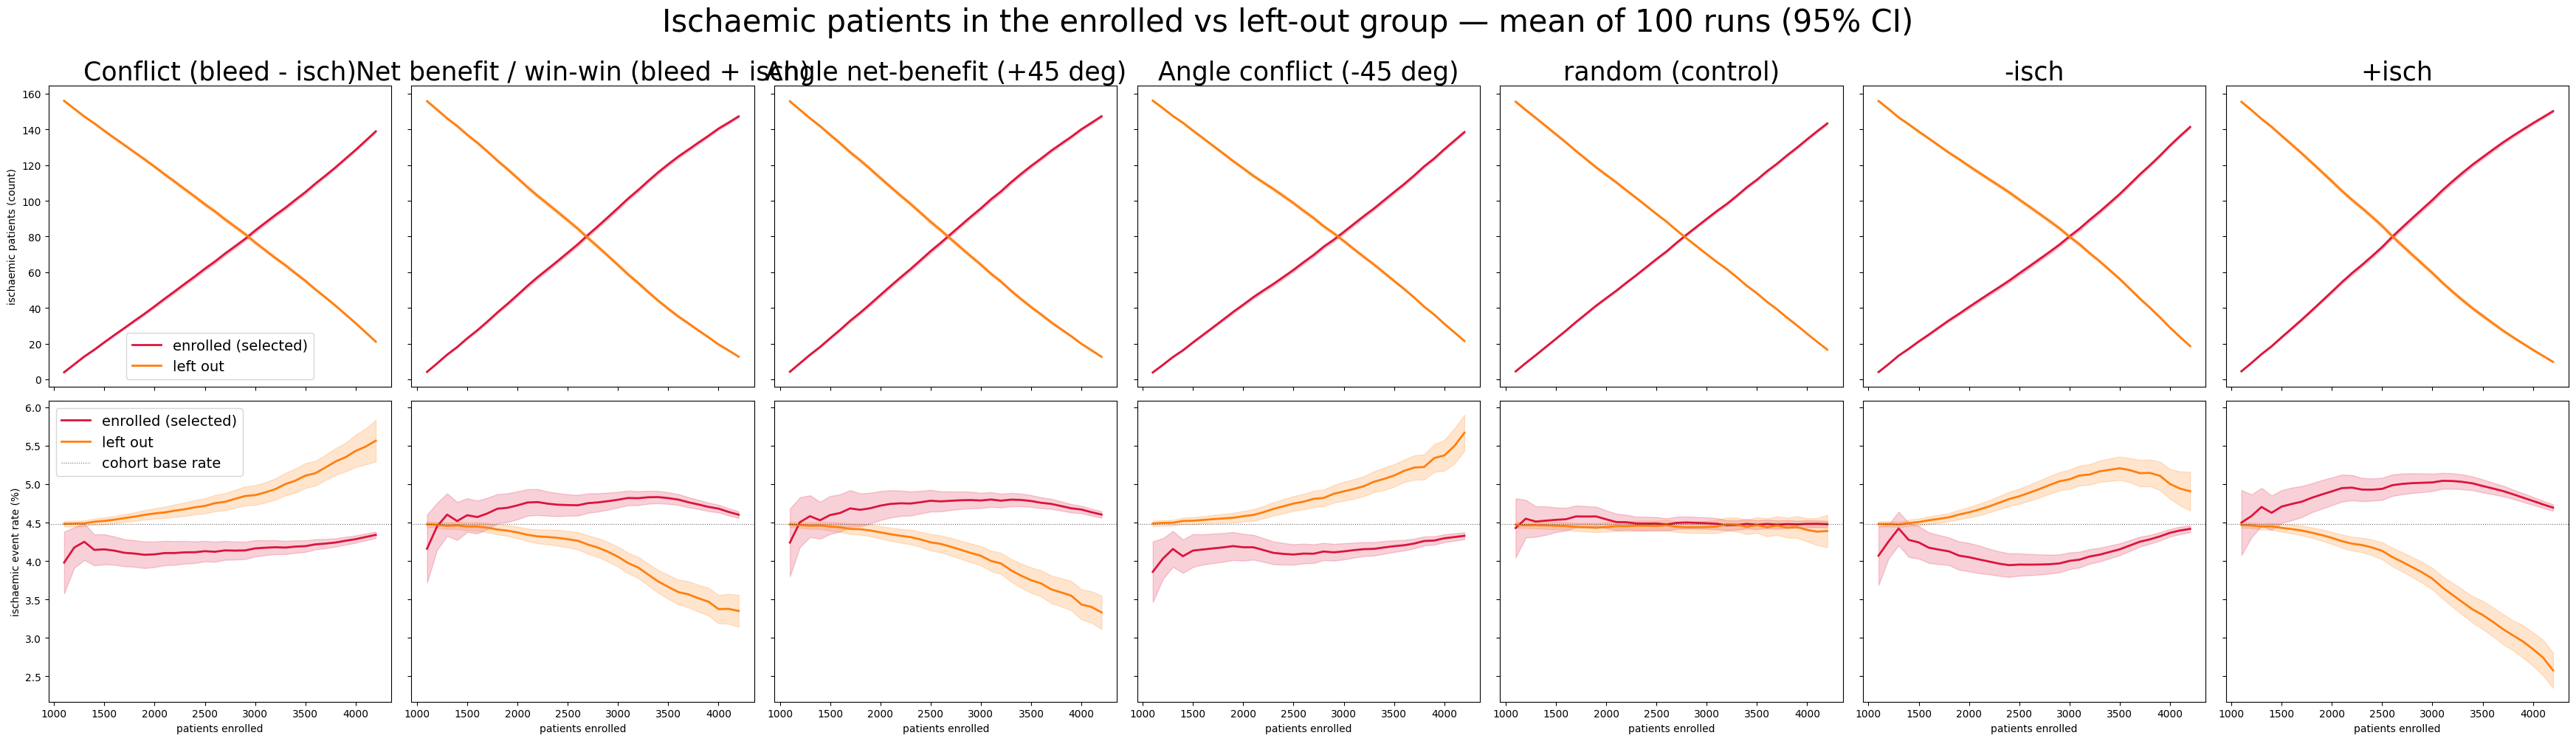

In [24]:
from scipy.stats import t

pol_run = [p for p in POLICIES_TO_RUN if p in set(summary['policy'])]
fig, axes = plt.subplots(2, len(pol_run), figsize=(5 * len(pol_run), 10),
                         sharex='col', sharey='row')
axes = np.atleast_2d(axes)

for ax_top, ax_bot, pol in zip(axes[0], axes[1], pol_run):
    s = summary[summary['policy'] == pol]

    for col, den, color, label in [
        ('new_isch_n', 'new_n', 'crimson', 'enrolled (selected)'),
        ('left_isch_n', 'left_n', 'tab:orange', 'left out')
    ]:
        m, e = s[f'{col}_mean'], s[f'{col}_sem']

        # Upper row: counts
        ax_top.plot(s['n'], m, color=color, lw=2, label=label)
        ax_top.fill_between(s['n'], m - e, m + e, color=color, alpha=.2)

        # Lower row: rates
        rate = s[f'{col}_mean'] / s[f'{den}_mean']
        rate_sem = e / s[f'{den}_mean']
        ci = t.ppf(0.975, N_RUNS - 1) * rate_sem

        ax_bot.plot(s['n'], rate * 100, color=color, lw=2, label=label)
        ax_bot.fill_between(
            s['n'],
            (rate - ci) * 100,
            (rate + ci) * 100,
            color=color,
            alpha=.2
        )

    ax_bot.axhline(
        ISCH_ANY.mean() * 100,
        color='k', lw=.8, ls=':', alpha=.6,
        label='cohort base rate'
    )

    ax_top.set_title(
        POLICIES[pol]['label'],
        fontsize=20,
        color='black'
    )
    ax_bot.set_xlabel('patients enrolled')

axes[0, 0].set_ylabel('ischaemic patients (count)')
axes[1, 0].set_ylabel('ischaemic event rate (%)')
axes[0, 0].legend(fontsize=14)
axes[1, 0].legend(fontsize=14)

fig.suptitle(
    f'Ischaemic patients in the enrolled vs left-out group — '
    f'mean of {N_RUNS} runs (95% CI)',
    y=1.00,
    fontsize=30
)

plt.tight_layout()
plt.savefig(
    os.path.join(os.getcwd(), '..', 'figures', 'policy_comparison_ischaemic_patients_only_mi.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 2. Ischaemic patients added per batch

The direct answer to "how many patients with an ischaemic event does each policy pull into
the trial?". Left: the per-batch count averaged over runs, batch by batch (the cohort base
rate x `BATCH_SIZE` is the no-selection expectation). Right: the same number collapsed to
one figure per policy, mean over all batches and runs with its across-run SEM.

The paired test below is on the **run-level** difference `selected rate - left-out rate`:
one number per run, so the `N_RUNS` runs are the unit of replication rather than the
individual patients. A one-sample t-test against 0 then asks whether the policy separates
the two groups at all. Caveat: the runs re-use the same underlying cohort (only the seed
draw and the enrolment path differ), so they are not fully independent and the p-value is
optimistic — read it as a descriptive summary, not a confirmatory test.

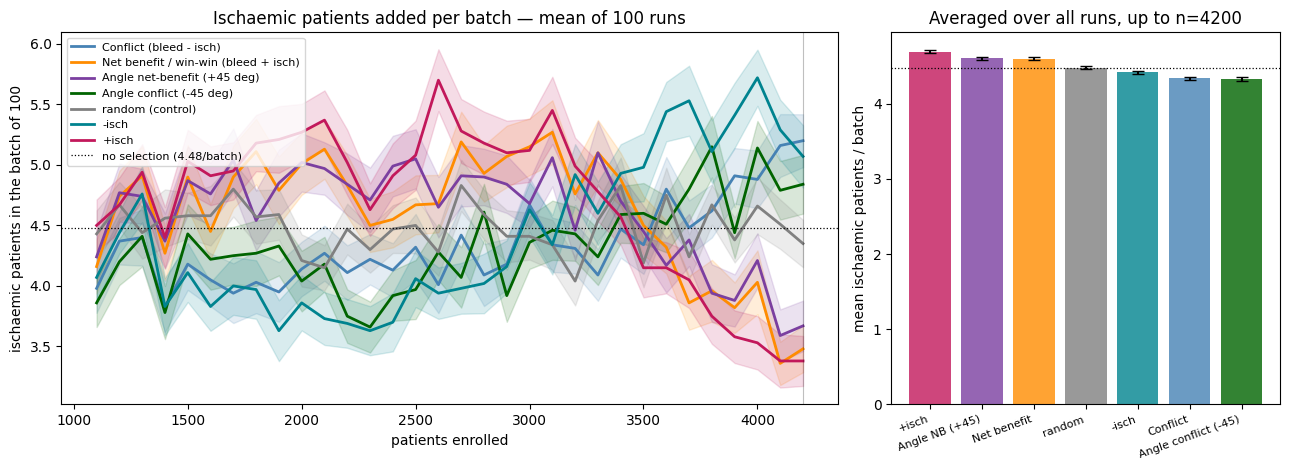

At n=4200 enrolled (379 still left out), selected vs left-out ischaemic rate, paired over 100 runs.
Negative diff = the policy is enrolling ischaemic patients later than the control.
           policy  isch_per_batch selected_rate leftout_rate diff_pp sem_pp     p
         conflict        4.340312         4.34%        5.56%   -1.22   0.15 0.000
      net_benefit        4.602500         4.60%        3.35%   +1.25   0.12 0.000
angle_net_benefit        4.604687         4.60%        3.33%   +1.27   0.12 0.000
   angle_conflict        4.328125         4.33%        5.67%   -1.34   0.13 0.000
           random        4.479375         4.48%        4.39%   +0.09   0.12 0.458
            -isch        4.418125         4.42%        4.91%   -0.49   0.14 0.001
            +isch        4.694063         4.69%        2.58%   +2.12   0.13 0.000


<Figure size 640x480 with 0 Axes>

In [25]:
from scipy import stats

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={'width_ratios': [2, 1]})

for pol in pol_run:
    s = summary[summary['policy'] == pol]
    m, e = s['batch_isch_n_mean'], s['batch_isch_n_sem']
    ax1.plot(s['n'], m, color=POLICIES[pol]['color'], lw=2, label=POLICIES[pol]['label'])
    ax1.fill_between(s['n'], m - e, m + e, color=POLICIES[pol]['color'], alpha=.15)

ax1.axhline(ISCH_ANY.mean() * BATCH_SIZE, color='k', lw=.9, ls=':',
            label=f'no selection ({ISCH_ANY.mean() * BATCH_SIZE:.2f}/batch)')
ax1.axvline(CHK_N, color='k', lw=.8, alpha=.25)
ax1.set(xlabel='patients enrolled', ylabel=f'ischaemic patients in the batch of {BATCH_SIZE}',
        title=f'Ischaemic patients added per batch — mean of {N_RUNS} runs')
ax1.legend(fontsize=8)

# -- per-run means -> one bar per policy, error bar = SEM across runs
per_run = (results[results['step'] <= CHK]
           .groupby(['policy', 'run'])['batch_isch_n'].mean().reset_index())
bar     = per_run.groupby('policy')['batch_isch_n'].agg(['mean', 'std', 'count'])
bar['sem'] = bar['std'] / np.sqrt(bar['count'])
bar = bar.reindex(pol_run)
bar = bar.sort_values('mean', ascending=False)

ax2.bar(range(len(bar)), bar['mean'], yerr=bar['sem'], capsize=4,
        color=[POLICIES[p]['color'] for p in bar.index], alpha=.8)
ax2.axhline(ISCH_ANY.mean() * BATCH_SIZE, color='k', lw=.9, ls=':')
ax2.set_xticks(range(len(bar)))
ax2.set_xticklabels([POLICIES[p]['short'] for p in bar.index], rotation=20, ha='right', fontsize=8)
ax2.set(ylabel='mean ischaemic patients / batch',
        title=f'Averaged over all runs, up to n={CHK_N}')
plt.tight_layout()
plt.show()

# -- run-level separation between the two groups, at the checkpoint
final = results[results['step'] == CHK].copy()
final = final.assign(new_rate=final['new_isch_n'] / final['new_n'],
                     left_rate=final['left_isch_n'] / final['left_n'])
final['diff_pp'] = (final['new_rate'] - final['left_rate']) * 100

rows = []
for pol in pol_run:
    d = final.loc[final['policy'] == pol, 'diff_pp']
    t, p = stats.ttest_1samp(d, 0.0)
    rows.append(dict(policy=pol,
                     isch_per_batch=bar.loc[pol, 'mean'],
                     selected_rate=f"{final.loc[final['policy'] == pol, 'new_rate'].mean():.2%}",
                     leftout_rate=f"{final.loc[final['policy'] == pol, 'left_rate'].mean():.2%}",
                     diff_pp=f'{d.mean():+.2f}',
                     sem_pp=f'{d.std() / np.sqrt(len(d)):.2f}',
                     p=f'{p:.3f}'))
print(f'At n={CHK_N} enrolled ({int(final["left_n"].mean())} still left out), selected vs left-out '
      f'ischaemic rate, paired over {N_RUNS} runs.\n'
      f'Negative diff = the policy is enrolling ischaemic patients later than the control.')
print(pd.DataFrame(rows).to_string(index=False))

plt.tight_layout()
plt.savefig(
    os.path.join(os.getcwd(), '..', 'figures', 'policy_comparison_discard_ischaemic_patients_only_mi.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

If we want to have a definitive answer at the question:

"Are this policies actuallly different from random selection in terms of the number of ischaemic patients they select into the trial?"

In [26]:
from scipy import stats
import numpy as np
import pandas as pd

final = results[results['step'] == CHK].copy()

# Event rates among selected patients
final['isch_rate'] = final['new_isch_n'] / final['new_n']
final['bleed_rate'] = final['batch_bleed_n'] / final['new_n']

# Random reference, matched by run
random = (
    final[final['policy'] == 'random']
    [['run', 'isch_rate', 'bleed_rate']]
    .rename(columns={
        'isch_rate': 'random_isch_rate',
        'bleed_rate': 'random_bleed_rate'
    })
)

comparison = (
    final[final['policy'] != 'random']
    [['policy', 'run', 'isch_rate', 'bleed_rate']]
    .merge(random, on='run', how='inner')
)

# Difference from random (percentage points)
comparison['isch_diff_pp'] = (
    comparison['isch_rate'] - comparison['random_isch_rate']
) * 100

comparison['bleed_diff_pp'] = (
    comparison['bleed_rate'] - comparison['random_bleed_rate']
) * 100

rows = []

for pol in pol_run:
    if pol == 'random':
        continue

    d_isch = comparison.loc[
        comparison['policy'] == pol, 'isch_diff_pp'
    ].dropna()

    d_bleed = comparison.loc[
        comparison['policy'] == pol, 'bleed_diff_pp'
    ].dropna()

    # Ischaemic:
    # all policies < random, except +isch > random
    isch_alt = 'greater' if pol == '+isch' else 'less'
    _, p_isch = stats.ttest_1samp(d_isch, 0, alternative=isch_alt)

    # Bleeding: policy < random
    _, p_bleed = stats.ttest_1samp(d_bleed, 0, alternative='less')

    rows.append({
        'Policy': pol,
        'Isch Δ (pp)': d_isch.mean(),
        'Isch SEM': d_isch.std(ddof=1) / np.sqrt(len(d_isch)),
        'Isch p': p_isch,
        'Bleed Δ (pp)': d_bleed.mean(),
        'Bleed SEM': d_bleed.std(ddof=1) / np.sqrt(len(d_bleed)),
        'Bleed p': p_bleed
    })

summary_test = pd.DataFrame(rows)

print(f"\nSelected event rates vs random — n={CHK_N}")
print(f"Paired by run, N={N_RUNS}")
print("-" * 90)

isch_test_summary = summary_test[['Policy', 'Isch Δ (pp)', 'Isch SEM', 'Isch p']].sort_values(by='Isch p')
bleed_test_summary = summary_test[['Policy', 'Bleed Δ (pp)', 'Bleed SEM', 'Bleed p']].sort_values(by='Bleed p', ascending=False)

for i in range(len(summary_test)):
    isch_row = isch_test_summary.iloc[i]
    bleed_row = bleed_test_summary.iloc[i]

    isch_direction = "> random" if isch_row['Policy'] == '+isch' else "< random"

    print(
        f"{isch_row['Policy']:<20} "
        f"Isch: Δ={isch_row['Isch Δ (pp)']:+.2f} pp, "
        f"p={isch_row['Isch p']:.4g} ({isch_direction})   |   "
        f"{bleed_row['Policy']:<20} "
        f"Bleed: Δ={bleed_row['Bleed Δ (pp)']:+.2f} pp, "
        f"p={bleed_row['Bleed p']:.4g} (> random)"
    )


Selected event rates vs random — n=4200
Paired by run, N=100
------------------------------------------------------------------------------------------
+isch                Isch: Δ=+0.21 pp, p=6.603e-20 (> random)   |   -isch                Bleed: Δ=+0.02 pp, p=0.9389 (> random)
angle_conflict       Isch: Δ=-0.15 pp, p=2.196e-12 (< random)   |   conflict             Bleed: Δ=+0.01 pp, p=0.6322 (> random)
conflict             Isch: Δ=-0.14 pp, p=4.995e-10 (< random)   |   angle_conflict       Bleed: Δ=+0.00 pp, p=0.5619 (> random)
-isch                Isch: Δ=-0.06 pp, p=0.002328 (< random)   |   net_benefit          Bleed: Δ=+0.00 pp, p=0.5209 (> random)
angle_net_benefit    Isch: Δ=+0.13 pp, p=1 (< random)   |   angle_net_benefit    Bleed: Δ=-0.02 pp, p=0.09338 (> random)
net_benefit          Isch: Δ=+0.12 pp, p=1 (< random)   |   +isch                Bleed: Δ=-0.03 pp, p=0.006856 (> random)


Same `summary_test` as above, split into the two per-metric tables in `pol_run` order instead of sorted by p-value: `isch_test_summary` for the ischaemic comparison, `bleed_test_summary` for the bleeding one.

In [27]:
# unsorted, in pol_run order (the interleaved print above sorts each metric by p-value)
isch_test_summary = summary_test[['Policy', 'Isch Δ (pp)', 'Isch SEM', 'Isch p']]
bleed_test_summary = summary_test[['Policy', 'Bleed Δ (pp)', 'Bleed SEM', 'Bleed p']]

## 3. CATE drift — where the selected cohort sits on the reference plane

All panels use the frozen reference forest, so movement represents a different selected
sub-population rather than a changing scoring model.

* **bleed CATE** and **isch CATE** are the two uncentred reference axes.
* **net benefit / win-win** is their scalar sum `bleed + isch`.
* **clinical-zero win-win fraction** is the raw-axis share with `bleed>0` and `isch>0`; it is
  not the centred preferred tier of either Angle policy. The exact preferred tiers are centred
  Q1 for Angle net-benefit and original centred Q4 for Angle conflict.

> Embedded drift outputs predate both the scalar sign/name correction and the split of the two
> Angle directions. They are historical output only until a complete rerun.

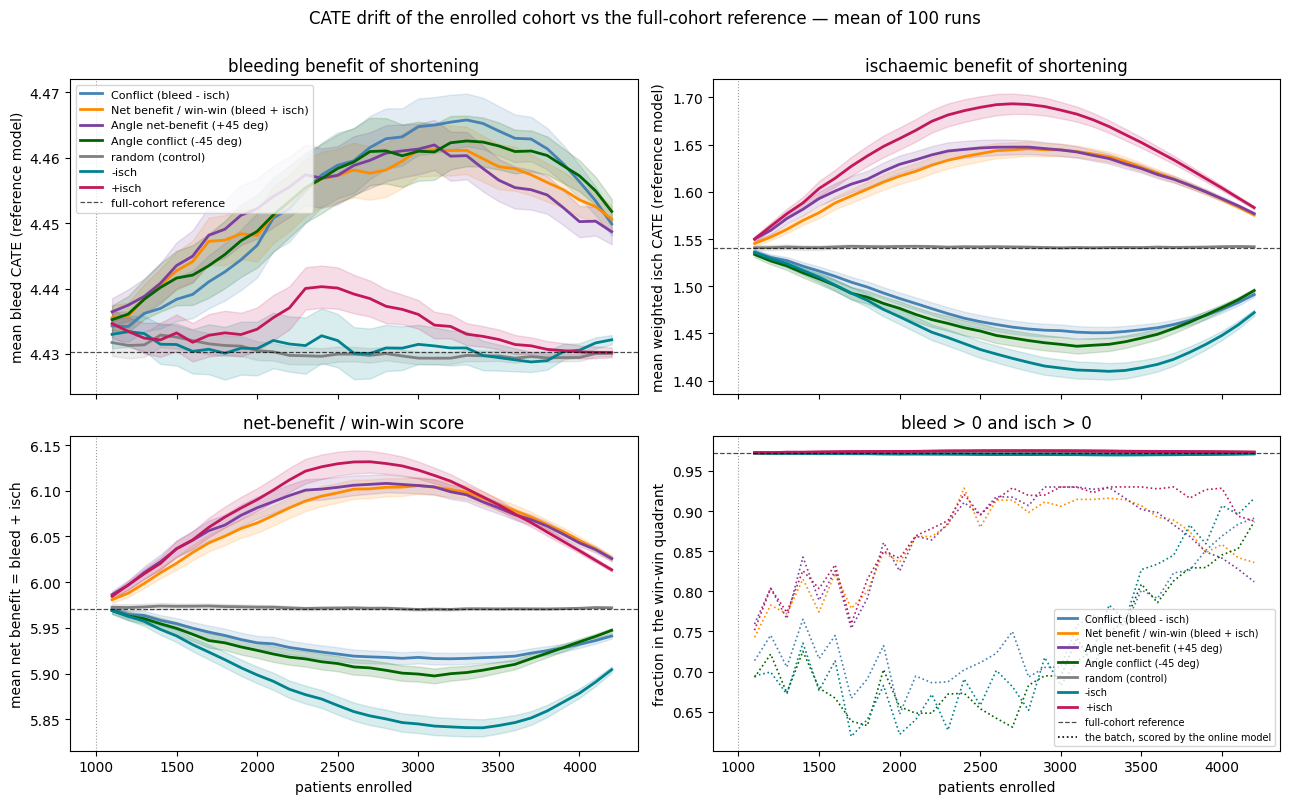

Enrolled cohort on the reference plane at n=4200:
                   ref_bleed_mean  ref_isch_mean  ref_net_benefit_mean  ref_q1_frac_mean
policy                                                                                  
conflict                   4.4499         1.4912                5.9411            0.9717
net_benefit                4.4506         1.5756                6.0262            0.9733
angle_net_benefit          4.4487         1.5770                6.0257            0.9734
angle_conflict             4.4518         1.4955                5.9473            0.9717
random                     4.4301         1.5419                5.9720            0.9726
-isch                      4.4322         1.4722                5.9043            0.9711
+isch                      4.4302         1.5833                6.0135            0.9732
FULL COHORT                4.4304         1.5405                5.9709            0.9725


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

panels = [('ref_bleed', 'mean bleed CATE (reference model)', FULL_BLEED, 'bleeding benefit of shortening'),
          ('ref_isch', 'mean weighted isch CATE (reference model)', FULL_ISCH, 'ischaemic benefit of shortening'),
          ('ref_net_benefit', 'mean net benefit = bleed + isch', FULL_NET_BENEFIT, 'net-benefit / win-win score'),
          ('ref_q1_frac', 'fraction in the win-win quadrant', FULL_Q1, 'bleed > 0 and isch > 0')]

for ax, (col, ylab, full, title) in zip(axes.ravel(), panels):
    for pol in pol_run:
        s = summary[summary['policy'] == pol]
        m, e = s[f'{col}_mean'], s[f'{col}_sem']
        ax.plot(s['n'], m, color=POLICIES[pol]['color'], lw=2, label=POLICIES[pol]['label'])
        ax.fill_between(s['n'], m - e, m + e, color=POLICIES[pol]['color'], alpha=.15)
    ax.axhline(full, color='k', lw=.9, ls='--', alpha=.7, label='full-cohort reference')
    ax.axvline(N_SEED, color='k', lw=.8, ls=':', alpha=.4)
    ax.set(ylabel=ylab, title=title)

# -- same win-win fraction, but as the ONLINE model that made the pick saw it
ax = axes[1, 1]
for pol in pol_run:
    s = summary[summary['policy'] == pol]
    if s['batch_q1_online_mean'].notna().any():
        ax.plot(s['n'], s['batch_q1_online_mean'], color=POLICIES[pol]['color'], lw=1.2, ls=':')
ax.plot([], [], color='k', lw=1.2, ls=':', label='the batch, scored by the online model')
ax.legend(fontsize=7)

axes[1, 0].set_xlabel('patients enrolled')
axes[1, 1].set_xlabel('patients enrolled')
axes[0, 0].legend(fontsize=8)
fig.suptitle(f'CATE drift of the enrolled cohort vs the full-cohort reference — mean of {N_RUNS} runs',
             y=1.00)
plt.tight_layout()
plt.show()

drift = (summary[summary['step'] == CHK]
         .set_index('policy')[['ref_bleed_mean', 'ref_isch_mean', 'ref_net_benefit_mean', 'ref_q1_frac_mean']]
         .reindex(pol_run))
drift.loc['FULL COHORT'] = [FULL_BLEED, FULL_ISCH, FULL_NET_BENEFIT, FULL_Q1]
for ax in axes.ravel():
    ax.axvline(CHK_N, color='k', lw=.8, ls='-', alpha=.25)

print(f'Enrolled cohort on the reference plane at n={CHK_N}:')
print(drift.round(4).to_string())

## 4. Where in the queue does an ischaemic patient end up?

Sections 1 and 2 read *rates* -- the share of ischaemic patients inside each group at a given
round. That answers "who is in the trial right now", not "in what order did the policy put
them", which is the only thing a ranking policy actually controls. With `N_STOP` close to
`len(X)` every policy ends up enrolling almost the same people and the rate difference
collapses by conservation, exactly as `checkpoint_step`'s docstring warns; the ordering does
not collapse, because order is what the policy *is*.

`mean_enrol_position` reduces a whole run to one number: the average position in the enrolment
queue of the patients who really had an ischaemic event. Higher = enrolled later = the policy
is pushing them to the back, which is what the design is for. Two reference points bracket it,
both computed with the seed cohort held fixed:

* **floor** -- every non-seed ischaemic patient enrolled immediately after the seed;
* **ceiling** -- every one of them enrolled last.

The distance from `random` to the ceiling is the headroom a policy actually has, and
`pct_of_headroom` reports each policy against it. The seed cohort of `N_SEED` patients is drawn
at random and enrolled unconditionally, so the ischaemic patients that land in it are out of
every policy's reach and pull both bounds towards the middle -- shrinking `N_SEED` is the one
lever that widens this whole scale.

In [29]:
from scipy import stats

TOT_ISCH   = int(ISCH_ANY.sum())
N_STOP_ACT = int(results['n'].max())          # where enrolment actually stopped


def mean_enrol_position(g):
    """Mean position in the enrolment queue of a patient with a real ischaemic event.

    The seed cohort is drawn at random and enrolled unconditionally, so its ischaemic patients
    sit at mean position `N_SEED/2` whatever the policy does -- they are the part of the
    ordering no policy can touch. Patients the run never reached (enrolment stops at
    `N_STOP_ACT`) are charged the mean position of the residual pool: they are last in the
    queue, which is precisely what a deferring policy is trying to achieve, so dropping them
    would silently discard the patients the policy most succeeded in avoiding."""
    g         = g.sort_values('step')
    seed_isch = g['enr_isch_n'].iloc[0] - g['batch_isch_n'].iloc[0]
    cnt       = g['batch_isch_n'].to_numpy()
    pos       = g['n'].to_numpy() - BATCH_SIZE / 2                  # centre of each batch
    never     = TOT_ISCH - seed_isch - cnt.sum()
    return (seed_isch * (N_SEED / 2)
            + (cnt * pos).sum()
            + never * (N_STOP_ACT + N) / 2) / TOT_ISCH


ISCH_POS = (results.groupby(['policy', 'run'])[['step', 'n', 'enr_isch_n', 'batch_isch_n']]
                   .apply(mean_enrol_position)
                   .rename('pos').reset_index()
                   .pivot(index='run', columns='policy', values='pos'))

# The two extremes the fixed seed cohort still allows.
step0     = results[results['step'] == 0]
SEED_ISCH = (step0['enr_isch_n'] - step0['batch_isch_n']).mean()
_k        = TOT_ISCH - SEED_ISCH
CEILING   = (SEED_ISCH * (N_SEED / 2) + _k * (N - _k / 2)) / TOT_ISCH
FLOOR     = (SEED_ISCH * (N_SEED / 2) + _k * (N_SEED + _k / 2)) / TOT_ISCH
HEADROOM  = CEILING - ISCH_POS['random'].mean()

rows = []
for pol in pol_run:
    d = ISCH_POS[pol] - ISCH_POS['random']
    rows.append(dict(policy=pol,
                     mean_position=round(ISCH_POS[pol].mean(), 1),
                     vs_random=round(d.mean(), 1),
                     sem=round(d.std() / np.sqrt(len(d)), 1),
                     p=np.nan if pol == 'random' else round(stats.ttest_1samp(d, 0.0)[1], 4),
                     pct_of_headroom=f'{d.mean() / HEADROOM:.1%}',
                     runs_deferring='-' if pol == 'random' else f'{int((d > 0).sum())}/{len(d)}'))

print(f'Mean position in the enrolment queue of the {TOT_ISCH} patients with a real ischaemic '
      f'event, out of {N}.\nHigher = enrolled later = the policy is pushing them to the back, '
      f'which is the stated goal.\nPaired against `random` on the same seed cohort, '
      f'{N_RUNS} runs.\n')
print(f'  floor   (all just after the seed) : {FLOOR:7.0f}')
print(f'  random  (control)                 : {ISCH_POS["random"].mean():7.0f}')
print(f'  ceiling (all last)                : {CEILING:7.0f}   <- {SEED_ISCH:.0f} of them sit in '
      f'the random seed cohort and cannot be moved at all\n')
print(pd.DataFrame(rows).sort_values('mean_position', ascending=False).to_string(index=False))

Mean position in the enrolment queue of the 205 patients with a real ischaemic event, out of 4579.
Higher = enrolled later = the policy is pushing them to the back, which is the stated goal.
Paired against `random` on the same seed cohort, 100 runs.

  floor   (all just after the seed) :     953
  random  (control)                 :    2281
  ceiling (all last)                :    3621   <- 45 of them sit in the random seed cohort and cannot be moved at all

           policy  mean_position  vs_random  sem   p pct_of_headroom runs_deferring
            -isch         2369.9       88.6 11.4 0.0            6.6%         72/100
   angle_conflict         2361.7       80.4 10.9 0.0            6.0%         72/100
         conflict         2360.5       79.2 11.4 0.0            5.9%         69/100
           random         2281.3        0.0  0.0 NaN            0.0%              -
angle_net_benefit         2216.9      -64.4 11.8 0.0           -4.8%         30/100
      net_benefit         2215.4 

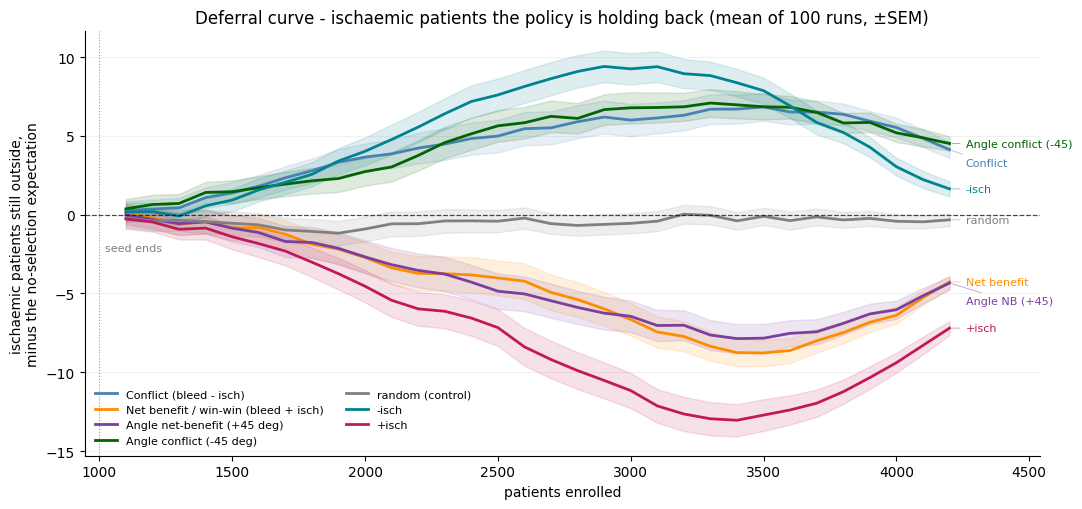

In [30]:
# Ischaemic patients still OUTSIDE the trial, minus how many would still be outside under no
# selection at all. Positive = the policy is holding them back.
defer = results.assign(deferred=results['left_isch_n'] - TOT_ISCH * results['left_n'] / N)
curve = (defer.groupby(['policy', 'step'])
              .agg(n=('n', 'mean'), m=('deferred', 'mean'),
                   sd=('deferred', 'std'), k=('deferred', 'count'))
              .reset_index())
curve['sem'] = curve['sd'] / np.sqrt(curve['k'])

fig, ax = plt.subplots(figsize=(11, 5.2))
ends = []
for pol in pol_run:
    s = curve[curve['policy'] == pol]
    ax.plot(s['n'], s['m'], color=POLICIES[pol]['color'], lw=2, label=POLICIES[pol]['label'])
    ax.fill_between(s['n'], s['m'] - s['sem'], s['m'] + s['sem'],
                    color=POLICIES[pol]['color'], alpha=.13)
    ends.append((s['m'].iloc[-1], s['n'].iloc[-1], pol))

# Direct end-labels so identity is never colour-alone, nudged apart top-down so the policies
# that finish on top of each other stay readable.
gap, prev = .055 * np.ptp(curve['m']), None
for y, x, pol in sorted(ends, reverse=True):
    y_lab = y if prev is None else min(y, prev - gap)
    ax.annotate(POLICIES[pol]['short'], xy=(x, y), xytext=(x + 60, y_lab), fontsize=8, va='center',
                color=POLICIES[pol]['color'], annotation_clip=False,
                arrowprops=dict(arrowstyle='-', lw=.6, color=POLICIES[pol]['color'], alpha=.5))
    prev = y_lab

ax.axhline(0, color='k', lw=.9, ls='--', alpha=.7)
ax.axvline(N_SEED, color='k', lw=.8, ls=':', alpha=.4)
ax.annotate('seed ends', (N_SEED, 0), xytext=(4, -26), textcoords='offset points',
            fontsize=8, alpha=.5)
ax.grid(axis='y', lw=.4, alpha=.3)
ax.set_axisbelow(True)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
ax.set(xlabel='patients enrolled',
       ylabel='ischaemic patients still outside,\nminus the no-selection expectation',
       title=f'Deferral curve - ischaemic patients the policy is holding back '
             f'(mean of {N_RUNS} runs, ±SEM)')
ax.set_xlim(right=N_STOP_ACT + 340)
ax.legend(fontsize=8, ncol=2, frameon=False)
plt.tight_layout()
plt.show()

## 5. Which axis moved the queue -- and does the ischaemic axis pass the mirror test?

> **Run-status reminder:** embedded results predate the corrected scalar convention and the
> distinct +45°/-45° Angle policies. Do not attribute those displayed values to the current
> policy names before rerunning the notebook.

**Left.** Each policy is represented by its paired movement relative to random on the frozen
(bleed, isch) plane. Under the required convention,
`conflict = bleed - isch` and `net_benefit = bleed + isch`.

**Right.** The mirror test asks whether movement on the estimated ischaemic axis predicts
movement of real ischaemic-event patients in the queue. Its free intercept measures whether
another axis can shift those patients even when estimated ischaemic movement is zero.

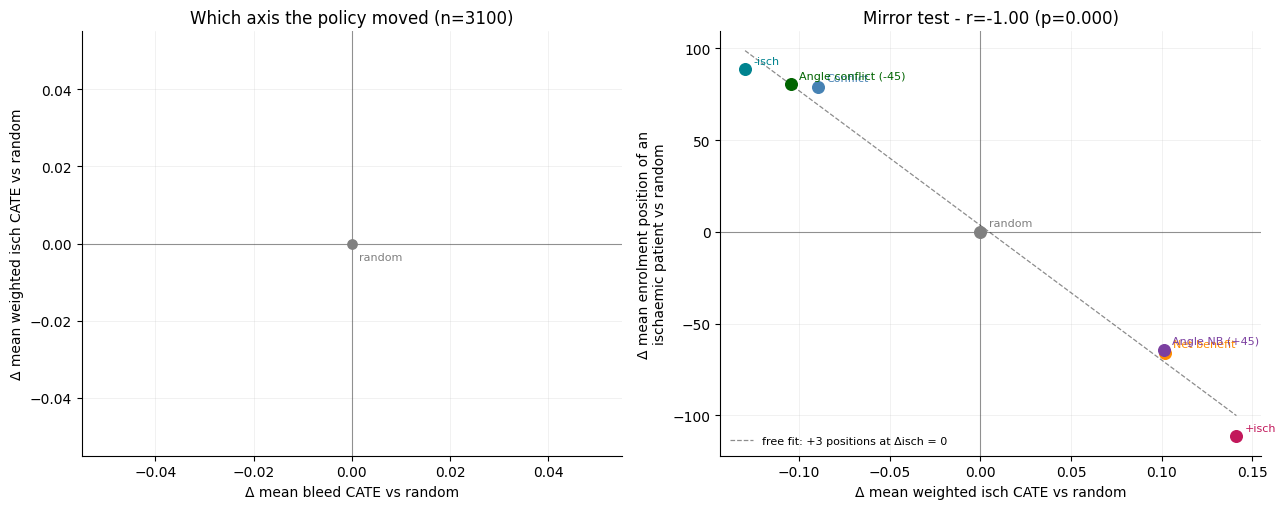

Axis read at step 20 (n=3100, 1479 still in the pool). Δ = paired mean difference vs random; d_pos in queue positions.
           policy  d_bleed  d_isch     d_pos
         conflict   0.0356 -0.0897   79.2330
      net_benefit   0.0319  0.1016  -65.9299
angle_net_benefit   0.0326  0.1011  -64.3970
   angle_conflict   0.0315 -0.1047   80.4448
            -isch   0.0019 -0.1298   88.5581
            +isch   0.0051  0.1412 -111.5725


In [31]:
# Read where the pool is still about a third of the cohort: late enough that the policy has had
# many rounds to act, early enough that it still has something left to choose from.
STEP_AX = int(results.loc[(results['left_n'] / N - 1 / 3).abs().idxmin(), 'step'])
axf     = results[results['step'] == STEP_AX]
D       = {c: axf.pivot(index='run', columns='policy', values=c) for c in ('ref_bleed', 'ref_isch')}

pts = pd.DataFrame([dict(policy=pol,
                         d_bleed=(D['ref_bleed'][pol] - D['ref_bleed']['random']).mean(),
                         d_isch=(D['ref_isch'][pol] - D['ref_isch']['random']).mean(),
                         d_pos=(ISCH_POS[pol] - ISCH_POS['random']).mean())
                    for pol in pol_run if pol != 'random'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))

# -- left: which of the two CATE axes each policy actually moved
for _, r in pts.iterrows():
    c = POLICIES[r['policy']]['color']
    ax1.annotate('', xy=(r['d_bleed'], r['d_isch']), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='-|>', color=c, lw=1.8, shrinkA=0, shrinkB=0))
    ax1.annotate(POLICIES[r['policy']]['short'], (r['d_bleed'], r['d_isch']), xytext=(5, 4),
                 textcoords='offset points', fontsize=8, color=c)
ax1.scatter(0, 0, s=45, color=POLICIES['random']['color'], zorder=3)
ax1.annotate('random', (0, 0), xytext=(5, -12), textcoords='offset points',
             fontsize=8, color=POLICIES['random']['color'])
ax1.set(xlabel='Δ mean bleed CATE vs random', ylabel='Δ mean weighted isch CATE vs random',
        title=f'Which axis the policy moved (n={int(axf["n"].mean())})')

# -- right: the mirror test
for _, r in pts.iterrows():
    c = POLICIES[r['policy']]['color']
    ax2.scatter(r['d_isch'], r['d_pos'], s=70, color=c, zorder=3)
    ax2.annotate(POLICIES[r['policy']]['short'], (r['d_isch'], r['d_pos']), xytext=(6, 4),
                 textcoords='offset points', fontsize=8, color=c)
ax2.scatter(0, 0, s=70, color=POLICIES['random']['color'], zorder=3)
ax2.annotate('random', (0, 0), xytext=(6, 4), textcoords='offset points',
             fontsize=8, color=POLICIES['random']['color'])
rho, p_rho = stats.pearsonr(pts['d_isch'], pts['d_pos'])
slope, icept = np.polyfit(pts['d_isch'], pts['d_pos'], 1)
xg = np.array([pts['d_isch'].min(), pts['d_isch'].max()])
ax2.plot(xg, slope * xg + icept, color='k', lw=.9, ls='--', alpha=.45, zorder=1,
         label=f'free fit: {icept:+.0f} positions at Δisch = 0')
ax2.legend(fontsize=8, frameon=False, loc='lower left')
ax2.set(xlabel='Δ mean weighted isch CATE vs random',
        ylabel='Δ mean enrolment position of an\nischaemic patient vs random',
        title=f'Mirror test - r={rho:+.2f} (p={p_rho:.3f})')

for ax in (ax1, ax2):
    ax.axhline(0, color='k', lw=.8, alpha=.4)
    ax.axvline(0, color='k', lw=.8, alpha=.4)
    ax.grid(lw=.4, alpha=.3)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Axis read at step {STEP_AX} (n={int(axf["n"].mean())}, '
      f'{int(axf["left_n"].mean())} still in the pool). Δ = paired mean difference vs random; '
      f'd_pos in queue positions.')
print(pts.round(4).to_string(index=False))

## 6. How sure is the model at the end of the trial?

Two different questions, and they are not the same one.

**Is the ranking worth anything?** `autoc_lb` is the cross-validated AUTOC lower confidence
bound (`score_cv_autoc` at `z=1`), recomputed on the enrolled cohort every `autoc_every`
patients. It is the targeting gain the model can still claim once the winner's-curse penalty
is subtracted: above zero the model's own ordering demonstrably beats enrolling at random,
below zero it cannot be shown to, however confident the point estimate looks. This one is
already in `results` and needs no re-run.

**How wide are the CATEs themselves?** `se_bleed` / `se_isch` are the forest's
bootstrap-of-little-bags standard errors from `predict_cate_std`, averaged over the whole
cohort so the reference population is fixed and the number stays comparable across policies
and across rounds. `se_isch_pool` restricts the same average to the patients still in the
pool -- the ones the policy has yet to rank, and the only ones where being unsure still costs
it anything. These need `unc_every` set, which `run_all` now passes; the cell below says so
plainly when the loaded `results` predates it.

Two caveats to read them with:

* Enrolment stops at `N_STOP`, and at 3500 of 4579 every policy is holding 76% of the *same*
  patients -- so "at the end of the trial" is nearly policy-independent **by construction**.
  For the comparison to carry information, read it mid-trial, or lower `N_STOP` so the arms
  still hold genuinely different cohorts when the trial closes.
* `random` never fits a forest (`frame=None` short-circuits the loop), so it contributes no
  standard errors at all. The control for that panel is equal `n`, not the `random` arm.

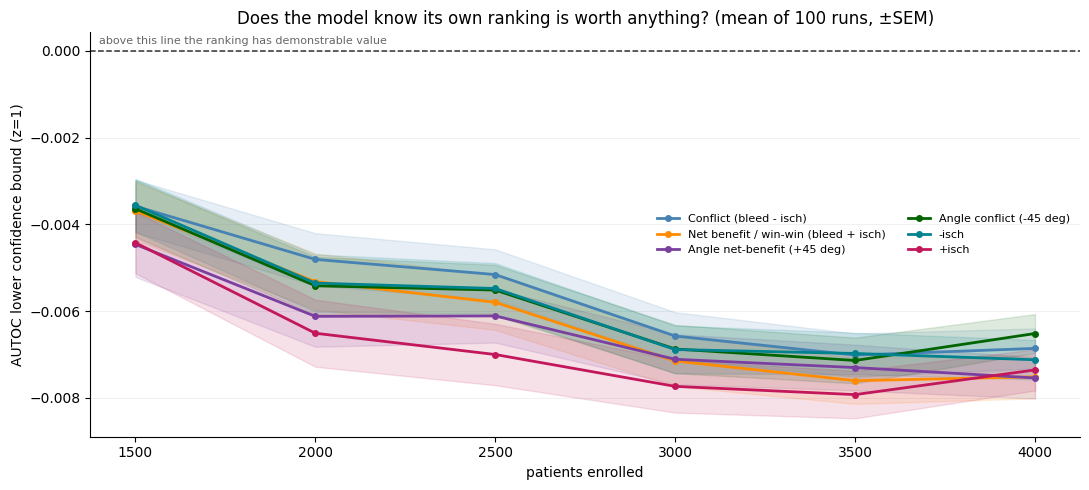

AUTOC lower bound at the last checkpoint (n=4000), 100 runs.
The targeting gain the model can still claim after the winner's-curse penalty.
Below zero = at this sample size the ranking cannot be shown to beat enrolling
at random, whatever the point estimate says.

           policy  autoc_lb     sem runs_above_0  p_vs_0
   angle_conflict  -0.00652 0.00045        0/100     0.0
         conflict  -0.00686 0.00046        0/100     0.0
            -isch  -0.00712 0.00046        0/100     0.0
            +isch  -0.00736 0.00047        0/100     0.0
      net_benefit  -0.00751 0.00050        0/100     0.0
angle_net_benefit  -0.00754 0.00047        0/100     0.0


In [32]:
au = results[results['autoc_lb'].notna()]
if au.empty:
    print('No `autoc_lb` recorded -- re-run `run_all` with `autoc_every` set.')
else:
    g = (au.groupby(['policy', 'step'])
           .agg(n=('n', 'mean'), m=('autoc_lb', 'mean'),
                sd=('autoc_lb', 'std'), k=('autoc_lb', 'count')).reset_index())
    g['sem'] = g['sd'] / np.sqrt(g['k'])

    fig, ax = plt.subplots(figsize=(11, 5))
    for pol in [p for p in pol_run if p in set(g['policy'])]:
        s = g[g['policy'] == pol]
        ax.plot(s['n'], s['m'], color=POLICIES[pol]['color'], lw=2, marker='o', ms=4,
                label=POLICIES[pol]['label'])
        ax.fill_between(s['n'], s['m'] - s['sem'], s['m'] + s['sem'],
                        color=POLICIES[pol]['color'], alpha=.13)
    ax.axhline(0, color='k', lw=1.1, ls='--', alpha=.8)
    ax.annotate('above this line the ranking has demonstrable value', (ax.get_xlim()[0], 0),
                xytext=(6, 5), textcoords='offset points', fontsize=8, alpha=.6)
    ax.grid(axis='y', lw=.4, alpha=.3)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    ax.set(xlabel='patients enrolled', ylabel='AUTOC lower confidence bound (z=1)',
           title=f'Does the model know its own ranking is worth anything? '
                 f'(mean of {N_RUNS} runs, ±SEM)')
    ax.legend(fontsize=8, ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()

    last = au[au['step'] == int(au['step'].max())]
    rows = [dict(policy=pol,
                 autoc_lb=round(d.mean(), 5), sem=round(d.std() / np.sqrt(len(d)), 5),
                 runs_above_0=f'{int((d > 0).sum())}/{len(d)}',
                 p_vs_0=round(stats.ttest_1samp(d, 0.0)[1], 4))
            for pol in pol_run
            if len(d := last.loc[last['policy'] == pol, 'autoc_lb'].dropna())]
    print(f'AUTOC lower bound at the last checkpoint (n={int(last["n"].mean())}), {N_RUNS} runs.\n'
          f'The targeting gain the model can still claim after the winner\'s-curse penalty.\n'
          f'Below zero = at this sample size the ranking cannot be shown to beat enrolling\n'
          f'at random, whatever the point estimate says.\n')
    print(pd.DataFrame(rows).sort_values('autoc_lb', ascending=False).to_string(index=False))

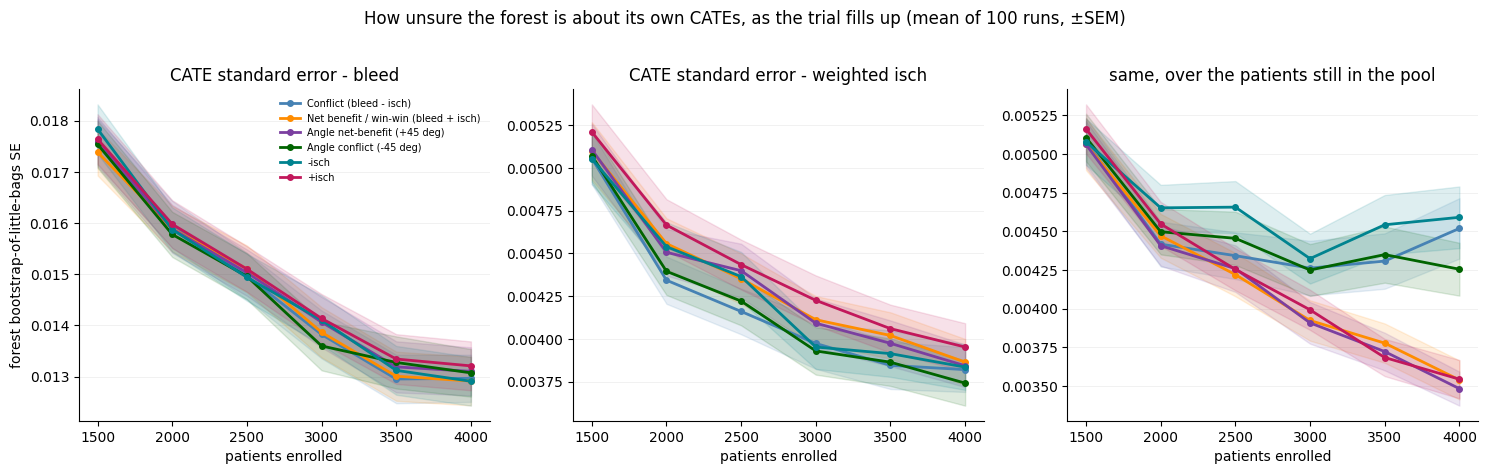

CATE standard errors at the last checkpoint (n=4000).
Lower = the model ends the trial more certain. A policy that is really buying
information ends BELOW the others at the same n.

           policy  se_bleed  se_isch  se_isch_pool
         conflict   0.01297  0.00382       0.00452
      net_benefit   0.01291  0.00386       0.00354
angle_net_benefit   0.01310  0.00384       0.00348
   angle_conflict   0.01307  0.00374       0.00425
            -isch   0.01291  0.00383       0.00459
            +isch   0.01321  0.00395       0.00354

NOTE: `random` never fits a forest, so it has no SE to compare against. The
      control here is equal `n`, not the random arm -- read the spread between
      the policies, and remember they all hold ~the same patients by the end.


In [33]:
SE_COLS = ['se_bleed', 'se_isch', 'se_isch_pool']
have_se = set(SE_COLS) <= set(results.columns) and results[SE_COLS].notna().any().any()

if not have_se:
    print('No CATE standard errors in `results`: this run predates `unc_every`.\n'
          'Re-run `run_all()` (it already passes `unc_every=500`) to fill\n'
          f'{SE_COLS} -- one `predict_cate_std` call per checkpoint, ~2.4 s each.')
else:
    se = results[results['se_isch'].notna()]
    g  = (se.groupby(['policy', 'step'])
            .agg(n=('n', 'mean'),
                 **{f'{c}_{s}': (c, s) for c in SE_COLS for s in ('mean', 'sem')})
            .reset_index())

    panels = [('se_bleed',     'CATE standard error - bleed'),
              ('se_isch',      'CATE standard error - weighted isch'),
              ('se_isch_pool', 'same, over the patients still in the pool')]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True)
    for ax, (col, title) in zip(axes, panels):
        for pol in [p for p in pol_run if p in set(g['policy'])]:
            s = g[g['policy'] == pol]
            m, e = s[f'{col}_mean'], s[f'{col}_sem']
            ax.plot(s['n'], m, color=POLICIES[pol]['color'], lw=2, marker='o', ms=4,
                    label=POLICIES[pol]['label'])
            ax.fill_between(s['n'], m - e, m + e, color=POLICIES[pol]['color'], alpha=.13)
        ax.grid(axis='y', lw=.4, alpha=.3)
        ax.set_axisbelow(True)
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        ax.set(xlabel='patients enrolled', title=title)
    axes[0].set_ylabel('forest bootstrap-of-little-bags SE')
    axes[0].legend(fontsize=7, frameon=False)
    fig.suptitle('How unsure the forest is about its own CATEs, as the trial fills up '
                 f'(mean of {N_RUNS} runs, ±SEM)', y=1.02)
    plt.tight_layout()
    plt.show()

    last = se[se['step'] == int(se['step'].max())]
    piv  = {c: last.pivot(index='run', columns='policy', values=c) for c in SE_COLS}
    ref  = 'random' if 'random' in piv['se_isch'].columns else None
    rows = []
    for pol in [p for p in pol_run if p in piv['se_isch'].columns]:
        r = dict(policy=pol, **{c: round(piv[c][pol].mean(), 5) for c in SE_COLS})
        if ref and pol != ref:
            d = (piv['se_isch'][pol] - piv['se_isch'][ref]).dropna()
            r['se_isch_vs_random'], r['p'] = round(d.mean(), 5), round(stats.ttest_1samp(d, 0.0)[1], 4)
        rows.append(r)
    print(f'CATE standard errors at the last checkpoint (n={int(last["n"].mean())}).\n'
          f'Lower = the model ends the trial more certain. A policy that is really buying\n'
          f'information ends BELOW the others at the same n.\n')
    print(pd.DataFrame(rows).to_string(index=False))
    if ref is None:
        print('\nNOTE: `random` never fits a forest, so it has no SE to compare against. The\n'
              '      control here is equal `n`, not the random arm -- read the spread between\n'
              '      the policies, and remember they all hold ~the same patients by the end.')